In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:


df = pd.read_csv("Diwali Sales Data.csv", encoding='latin1')

df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [4]:
df.shape

(11251, 15)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [9]:
df.columns 

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount', 'Status', 'unnamed1'],
      dtype='object')

In [11]:
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount,Status,unnamed1
count,1.125100e+04,11251.000000,11251.000000,11251.000000,11239.000000,0.0,0.0
mean,1.003004e+06,35.421207,0.420318,2.489290,9453.610858,NaN,NaN
std,1.716125e+03,12.754122,0.493632,1.115047,5222.355869,NaN,NaN
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000,NaN,NaN
25%,1.001492e+06,27.000000,0.000000,1.500000,5443.000000,NaN,NaN
50%,1.003065e+06,33.000000,0.000000,2.000000,8109.000000,NaN,NaN
75%,1.004430e+06,43.000000,1.000000,3.000000,12675.000000,NaN,NaN
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000,NaN,NaN


In [ ]:
Had a Basic Overview Of The Data 

In [18]:
df.isnull().sum()

User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64

In [29]:
  df = df.dropna(subset = ['Amount'])

In [30]:
df.isnull().sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

In [25]:
df.drop(['Status','unnamed1'], axis=1, inplace=True)

In [26]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [27]:
df.dtypes

User_ID               int64
Cust_name            object
Product_ID           object
Gender               object
Age Group            object
Age                   int64
Marital_Status        int64
State                object
Zone                 object
Occupation           object
Product_Category     object
Orders                int64
Amount              float64
dtype: object

In [28]:
df['Amount'] = df['Amount'].astype(int)

In [ ]:
Some columns contain missing values, especially in the Amount column.
Rows with missing purchase values were Removed  to ensure accurate analysis.

In [31]:
df.groupby('Gender')['Amount'].sum()

Gender
F    74430383
M    31932182
Name: Amount, dtype: int32

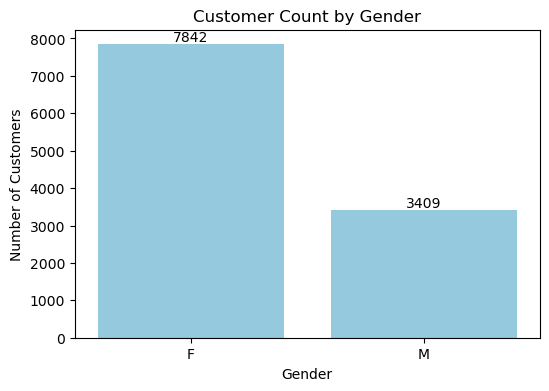

In [3]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='Gender', data=df, color='skyblue')

for container in ax.containers:
    ax.bar_label(container)
plt.title("Customer Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

Insight

Female customers contribute a larger share of the total sales compared to male customers.
This indicates that female shoppers are more active during the Diwali shopping season.

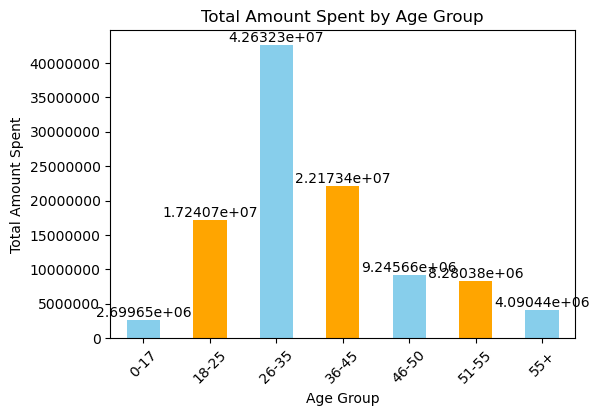

In [52]:

age_sales = df.groupby('Age Group')['Amount'].sum()

plt.figure(figsize=(6,4))

ax = age_sales.plot(kind='bar', color=['skyblue','orange'])

for container in ax.containers:
    ax.bar_label(container)

plt.title("Total Amount Spent by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Amount Spent")

plt.show()

Insight

The 26–35 age group spends the highest total amount among all age groups.
This suggests that young working professionals are the most active buyers during Diwali sales.

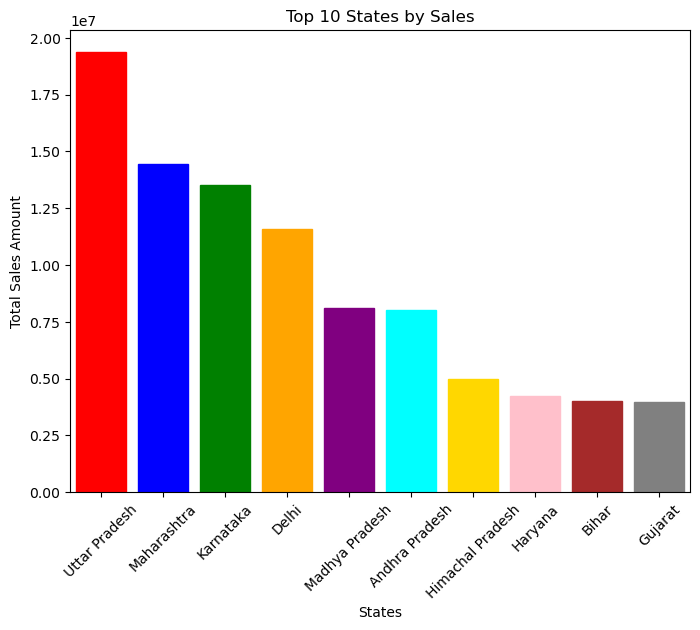

In [6]:
sales_state = df.groupby('State')['Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
ax = sns.barplot(x=sales_state.index, y=sales_state.values)

# different colors for each bar
colors = ['red','blue','green','orange','purple','cyan','gold','pink','brown','gray']

for i, bar in enumerate(ax.patches):
    bar.set_color(colors[i])

plt.title("Top 10 States by Sales")
plt.xlabel("States")
plt.ylabel("Total Sales Amount")

plt.xticks(rotation=45)

plt.show()

Insight

Uttar Pradesh, Maharashtra, and Karnataka generate the highest sales.
These states contribute significantly to the overall revenue during the Diwali sales period.

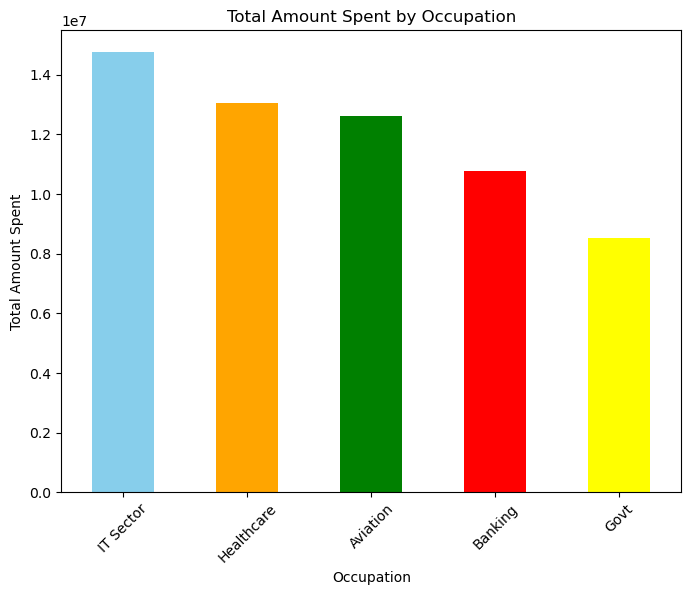

In [25]:
 occupation_sales = df.groupby('Occupation')['Amount'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(8,6))

occupation_sales.plot(kind = 'bar', color = ['skyblue','orange','Green','Red','Yellow']) 

plt.title("Total Amount Spent by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Total Amount Spent")

plt.xticks(rotation = 45)
plt.show()


Insight

Customers working in IT, Healthcare, and Aviation sectors contribute the highest sales.
This indicates that professionals with higher income levels tend to spend more during festive sales.

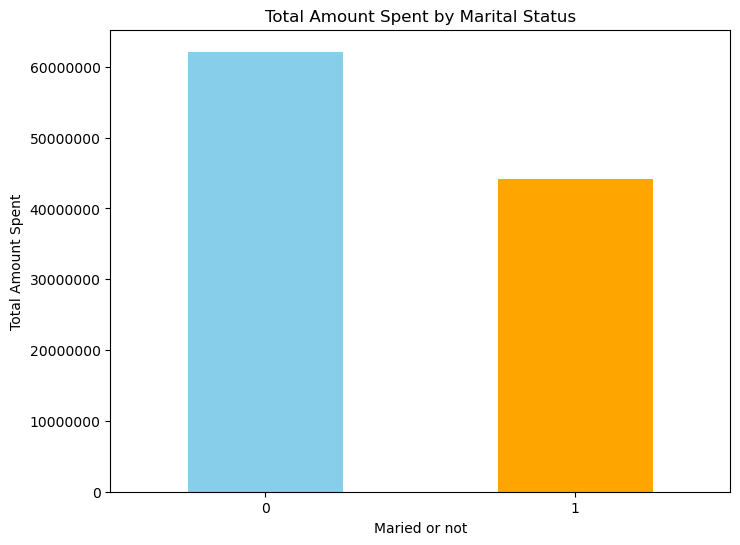

In [21]:
marital_sales = df.groupby('Marital_Status')['Amount'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(8,6))

marital_sales.plot(kind = 'bar', color=['skyblue','orange']) 

plt.title("Total Amount Spent by Marital Status")
plt.xlabel("Maried or not")
plt.ylabel("Total Amount Spent")

plt.xticks(rotation = 360)
plt.ticklabel_format(style='plain', axis='y')
plt.show()


Insight

Unmarried customers spend slightly more compared to married customers.
This may indicate that unmarried individuals tend to spend more on personal shopping during festivals..

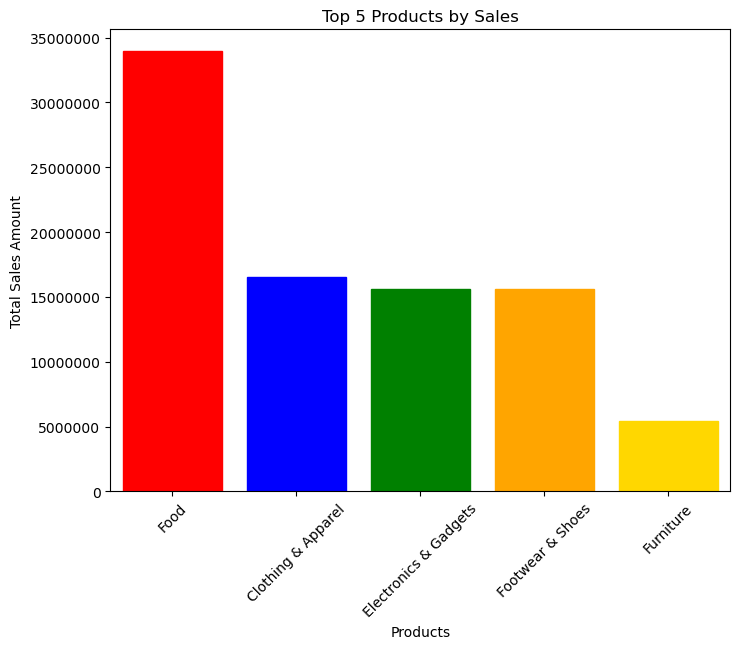

In [24]:
Product_sales = df.groupby('Product_Category')['Amount'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(8,6))
ax = sns.barplot(x=Product_sales.index, y=Product_sales.values)

# different colors for each bar
colors = ['red','blue','green','orange','gold']

for i, bar in enumerate(ax.patches):
    bar.set_color(colors[i])

plt.title("Top 5 Products by Sales")
plt.xlabel("Products")
plt.ylabel("Total Sales Amount")

plt.xticks(rotation=45)
plt.ticklabel_format(style = 'Plain', axis ='y')

plt.show()

Insight

Food, Clothing, and Electronics are the most popular product categories.
These categories dominate the Diwali shopping market.

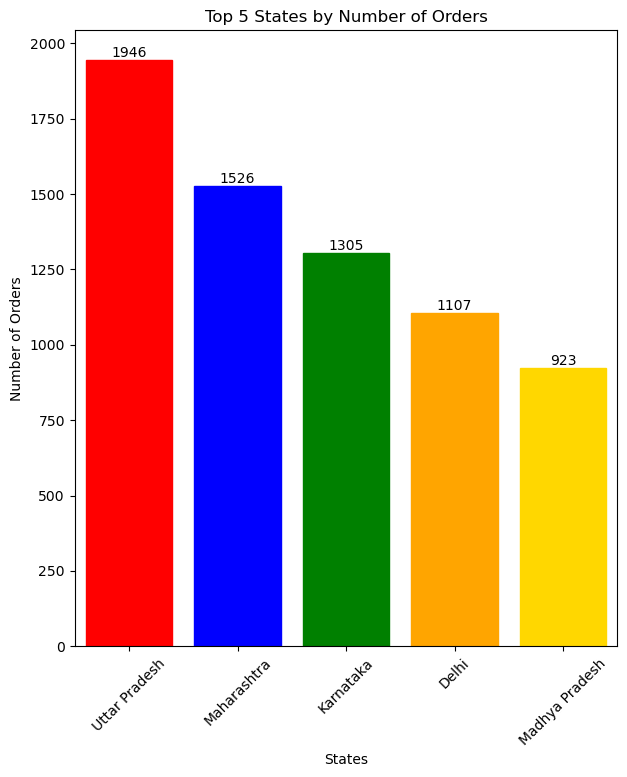

In [35]:
orders_sales = df.groupby('State')['Orders'].count().sort_values(ascending=False).head(5)

plt.figure(figsize=(7,8))

ax = sns.barplot(x=orders_sales.index, y=orders_sales.values)

for container in ax.containers:
    ax.bar_label(container)

# different colors for each bar
colors = ['red','blue','green','orange','gold']

for i, bar in enumerate(ax.patches):
    bar.set_color(colors[i])

plt.title("Top 5 States by Number of Orders")
plt.xlabel("States")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.ticklabel_format(style = 'Plain', axis ='y')

plt.show()

These are  The data of Most Number of Orders Per State in the sale Period Where Uttar pradesh Has Most Number of order 

Key Business Insights

Female customers dominate the shopping activity.

The 26–35 age group contributes the most revenue.

Uttar Pradesh and Maharashtra are the top revenue-generating states.

Professionals from IT and Healthcare sectors spend the most.

Food, Clothing, and Electronics are the most popular product categories during Diwali sales.